In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# <span style="color:red"> ch4. RNN(Recurrent Neural Network 순환신경망) </span>
# 1. 문맥을 이용하여 모델 만들기
- 짧은 문장을 넣어 모델을 만든다
## 1.1. 데이터 전처리

In [31]:
text = '''경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다'''
text1 = "장마철이 오고 있다"
# 텍스트 각 단어로 분리하여 숫자로 변환(원핫인코딩) -> 방대한 원핫을 임베딩 벡터로 곱해 줄여준다 
# 첫 단어부터 순차적으로 뒤의 단어로 연산이 되며 영향을 미친다

In [7]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()  # 토크나이저 객체를 생성
t.fit_on_texts([text, text1])
encoded = t.texts_to_sequences([text,text1])
print(encoded)
print(t.word_index) 
# 워드 인덱스에 딕셔너리로 각 토큰에 지정된 숫자를 볼 수 있다. 
# 숫자가 많아지면 for문을 계속 돌릴수는 없으니 이 딕셔너리의 키와 값을 바꾼 딕셔너리가 필요할것

[[3, 4, 1, 5, 2, 6, 1, 7, 8, 1, 9, 10, 1, 11], [12, 13, 2]]
{'말이': 1, '있다': 2, '경마장에': 3, '있는': 4, '뛰고': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11, '장마철이': 12, '오고': 13}


In [32]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()  # 토크나이저 객체를 생성
t.fit_on_texts([text])
encoded = t.texts_to_sequences([text])
print(encoded)
print(t.word_index) 

[[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11}


In [10]:
#  문자열 리스트를 인덱스 시퀀스 변화
print(t.texts_to_sequences(['경마장에 말이 있다', '말이 뛴다']))
print(t.texts_to_sequences(['가는 말이 곱다'])[0])

[[3, 1, 2], [1]]
[8, 1, 11]


In [18]:
t.word_index.items() # 각각을 튜플

dict_items([('말이', 1), ('있다', 2), ('경마장에', 3), ('있는', 4), ('뛰고', 5), ('그의', 6), ('법이다', 7), ('가는', 8), ('고와야', 9), ('오는', 10), ('곱다', 11), ('장마철이', 12), ('오고', 13)])

In [34]:
for key, value in t.word_index.items():
    print(key, value, end='\t')

말이 1	경마장에 2	있는 3	뛰고 4	있다 5	그의 6	법이다 7	가는 8	고와야 9	오는 10	곱다 11	

In [33]:
# 학습을 시키기 위해 연속된 조합을 만든다. 문장을 분리하고 시작인덱스/끝인덱스를 설정하여 조건반복실시
# ['경마장에 있는', '경마장에 있는 말이', 경마장에 있는 말이 뛰고] 
sequences = []
for line in text.split('\n'):
    print('원문장 :', line)
    encoded = t.texts_to_sequences([line])[0]  # 2차원 리스트로 만들어지므로 [0]를 넣어 1차원 리스트로 변경
    print('인코딩된 문장 :', encoded)
    for i in range(0, len(encoded)-1): # i : 시작인덱스로 설정
        for j in range(i+2,len(encoded)+1): # j : 끝나는 인덱스 + 1
            sequences.append(encoded[i:j])

print()
print('sequence와 해석 출력')
for sequence in sequences:
    print('[', end='')
    for word, value in t.word_index.items():
        for word_seq in sequence:

원문장 : 경마장에 있는 말이 뛰고 있다
인코딩된 문장 : [2, 3, 1, 4, 5]
원문장 : 그의 말이 법이다
인코딩된 문장 : [6, 1, 7]
원문장 : 가는 말이 고와야 오는 말이 곱다
인코딩된 문장 : [8, 1, 9, 10, 1, 11]

sequence와 해석 출력
[2, 3]
[2, 3, 1]
[2, 3, 1, 4]
[2, 3, 1, 4, 5]
[3, 1]
[3, 1, 4]
[3, 1, 4, 5]
[1, 4]
[1, 4, 5]
[4, 5]
[6, 1]
[6, 1, 7]
[1, 7]
[8, 1]
[8, 1, 9]
[8, 1, 9, 10]
[8, 1, 9, 10, 1]
[8, 1, 9, 10, 1, 11]
[1, 9]
[1, 9, 10]
[1, 9, 10, 1]
[1, 9, 10, 1, 11]
[9, 10]
[9, 10, 1]
[9, 10, 1, 11]
[10, 1]
[10, 1, 11]
[1, 11]


In [53]:
for sequence in sequences:
    print('[ ', end='')    
    for word_seq in sequence:
        for word, idx in t.word_index.items():
            if idx==word_seq:
                print(f'{word_seq}:{word}', end=' ')
    print(']')  

[ 2:경마장에 3:있는 ]
[ 2:경마장에 3:있는 1:말이 ]
[ 2:경마장에 3:있는 1:말이 4:뛰고 ]
[ 2:경마장에 3:있는 1:말이 4:뛰고 5:있다 ]
[ 3:있는 1:말이 ]
[ 3:있는 1:말이 4:뛰고 ]
[ 3:있는 1:말이 4:뛰고 5:있다 ]
[ 1:말이 4:뛰고 ]
[ 1:말이 4:뛰고 5:있다 ]
[ 4:뛰고 5:있다 ]
[ 6:그의 1:말이 ]
[ 6:그의 1:말이 7:법이다 ]
[ 1:말이 7:법이다 ]
[ 8:가는 1:말이 ]
[ 8:가는 1:말이 9:고와야 ]
[ 8:가는 1:말이 9:고와야 10:오는 ]
[ 8:가는 1:말이 9:고와야 10:오는 1:말이 ]
[ 8:가는 1:말이 9:고와야 10:오는 1:말이 11:곱다 ]
[ 1:말이 9:고와야 ]
[ 1:말이 9:고와야 10:오는 ]
[ 1:말이 9:고와야 10:오는 1:말이 ]
[ 1:말이 9:고와야 10:오는 1:말이 11:곱다 ]
[ 9:고와야 10:오는 ]
[ 9:고와야 10:오는 1:말이 ]
[ 9:고와야 10:오는 1:말이 11:곱다 ]
[ 10:오는 1:말이 ]
[ 10:오는 1:말이 11:곱다 ]
[ 1:말이 11:곱다 ]


In [61]:
# sequences를 훈련을 시킬 예정. 다만 각 요소의 길이가 달라 길이를 맞춰야 한다 : 패딩작업
my_len = max(len(sequence) for sequence in sequences)
print([len(sequence) for sequence in sequences])
print('가장 긴 sequence의 길이 :' , my_len)

# 패딩작업 시작 pad_sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequence = pad_sequences(sequences=sequences,
                               maxlen=my_len,
                               padding='pre')
padded_sequence.shape, type(padded_sequence)

[2, 3, 4, 5, 2, 3, 4, 2, 3, 2, 2, 3, 2, 2, 3, 4, 5, 6, 2, 3, 4, 5, 2, 3, 4, 2, 3, 2]
가장 긴 sequence의 길이 : 6


((28, 6), numpy.ndarray)

In [72]:
# 독립변수 X와 타겟변수 y로 분리
X = padded_sequence[:, :-1]
y = padded_sequence[:, -1]
X

array([[ 0,  0,  0,  0,  2],
       [ 0,  0,  0,  2,  3],
       [ 0,  0,  2,  3,  1],
       [ 0,  2,  3,  1,  4],
       [ 0,  0,  0,  0,  3],
       [ 0,  0,  0,  3,  1],
       [ 0,  0,  3,  1,  4],
       [ 0,  0,  0,  0,  1],
       [ 0,  0,  0,  1,  4],
       [ 0,  0,  0,  0,  4],
       [ 0,  0,  0,  0,  6],
       [ 0,  0,  0,  6,  1],
       [ 0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  8],
       [ 0,  0,  0,  8,  1],
       [ 0,  0,  8,  1,  9],
       [ 0,  8,  1,  9, 10],
       [ 8,  1,  9, 10,  1],
       [ 0,  0,  0,  0,  1],
       [ 0,  0,  0,  1,  9],
       [ 0,  0,  1,  9, 10],
       [ 0,  1,  9, 10,  1],
       [ 0,  0,  0,  0,  9],
       [ 0,  0,  0,  9, 10],
       [ 0,  0,  9, 10,  1],
       [ 0,  0,  0,  0, 10],
       [ 0,  0,  0, 10,  1],
       [ 0,  0,  0,  0,  1]])

In [66]:
# 컴퓨터가 X 데이터를 임베딩 작업할때 필요한 입력 bit 수 (단어수+1) : 
input_dim = len(t.word_index)+1
input_dim

12

In [71]:
# y처리를 위한 원핫인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, input_dim)
X.shape, Y.shape, input_dim

((28, 5), (28, 12), 12)

## 1.2. 모델 생성하기

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
# Embedding : Xi의 원핫인코딩한 희소행렬을 변환
# SimpleRNN : 
import matplotlib.pyplot as plt

model = Sequential()
model.add(Embedding(input_dim=input_dim,  # 12개로 원핫인코딩
                   output_dim=10, # 임베딩 출력의 갯수 (임의로 지정 가능)
                   input_length=X.shape[1])) # 입력(X)의 수(횟수)
model.add(SimpleRNN(32))  # units=32
model.add(Dense(12, activation='softmax'))
print(model.summary())



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5, 10)             120       
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1376      
                                                                 
 dense (Dense)               (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________
None


## 1.3. 모델 학습 과정 설정

In [75]:
model.compile(loss = 'categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

## 1.4. 모델 학습 시키기

In [76]:
hist = model.fit(X, Y, epochs=300, verbose=2)

Epoch 1/300
1/1 - 1s - loss: 2.4724 - accuracy: 0.0357 - 1s/epoch - 1s/step
Epoch 2/300
1/1 - 0s - loss: 2.4605 - accuracy: 0.0714 - 3ms/epoch - 3ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4485 - accuracy: 0.1071 - 5ms/epoch - 5ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4362 - accuracy: 0.1429 - 3ms/epoch - 3ms/step
Epoch 5/300
1/1 - 0s - loss: 2.4236 - accuracy: 0.1786 - 4ms/epoch - 4ms/step
Epoch 6/300
1/1 - 0s - loss: 2.4105 - accuracy: 0.1786 - 3ms/epoch - 3ms/step
Epoch 7/300
1/1 - 0s - loss: 2.3970 - accuracy: 0.2143 - 4ms/epoch - 4ms/step
Epoch 8/300
1/1 - 0s - loss: 2.3828 - accuracy: 0.2143 - 4ms/epoch - 4ms/step
Epoch 9/300
1/1 - 0s - loss: 2.3681 - accuracy: 0.2857 - 4ms/epoch - 4ms/step
Epoch 10/300
1/1 - 0s - loss: 2.3527 - accuracy: 0.3571 - 4ms/epoch - 4ms/step
Epoch 11/300
1/1 - 0s - loss: 2.3367 - accuracy: 0.4286 - 5ms/epoch - 5ms/step
Epoch 12/300
1/1 - 0s - loss: 2.3198 - accuracy: 0.3929 - 4ms/epoch - 4ms/step
Epoch 13/300
1/1 - 0s - loss: 2.3022 - accuracy: 0.4286 - 5ms/e

Epoch 105/300
1/1 - 0s - loss: 1.0561 - accuracy: 0.6786 - 4ms/epoch - 4ms/step
Epoch 106/300
1/1 - 0s - loss: 1.0448 - accuracy: 0.6786 - 3ms/epoch - 3ms/step
Epoch 107/300
1/1 - 0s - loss: 1.0338 - accuracy: 0.6786 - 4ms/epoch - 4ms/step
Epoch 108/300
1/1 - 0s - loss: 1.0230 - accuracy: 0.6786 - 4ms/epoch - 4ms/step
Epoch 109/300
1/1 - 0s - loss: 1.0125 - accuracy: 0.6786 - 3ms/epoch - 3ms/step
Epoch 110/300
1/1 - 0s - loss: 1.0021 - accuracy: 0.6786 - 4ms/epoch - 4ms/step
Epoch 111/300
1/1 - 0s - loss: 0.9919 - accuracy: 0.7143 - 3ms/epoch - 3ms/step
Epoch 112/300
1/1 - 0s - loss: 0.9819 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 113/300
1/1 - 0s - loss: 0.9721 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 114/300
1/1 - 0s - loss: 0.9625 - accuracy: 0.7143 - 3ms/epoch - 3ms/step
Epoch 115/300
1/1 - 0s - loss: 0.9531 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 116/300
1/1 - 0s - loss: 0.9439 - accuracy: 0.7500 - 4ms/epoch - 4ms/step
Epoch 117/300
1/1 - 0s - loss: 0.9348 - 

Epoch 208/300
1/1 - 0s - loss: 0.4554 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 209/300
1/1 - 0s - loss: 0.4523 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 210/300
1/1 - 0s - loss: 0.4492 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 211/300
1/1 - 0s - loss: 0.4461 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 212/300
1/1 - 0s - loss: 0.4430 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 213/300
1/1 - 0s - loss: 0.4400 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 214/300
1/1 - 0s - loss: 0.4370 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 215/300
1/1 - 0s - loss: 0.4341 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 216/300
1/1 - 0s - loss: 0.4311 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 217/300
1/1 - 0s - loss: 0.4282 - accuracy: 0.8929 - 4ms/epoch - 4ms/step
Epoch 218/300
1/1 - 0s - loss: 0.4254 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 219/300
1/1 - 0s - loss: 0.4225 - accuracy: 0.8929 - 3ms/epoch - 3ms/step
Epoch 220/300
1/1 - 0s - loss: 0.4197 - 

## 1.5. 모델 평가하기

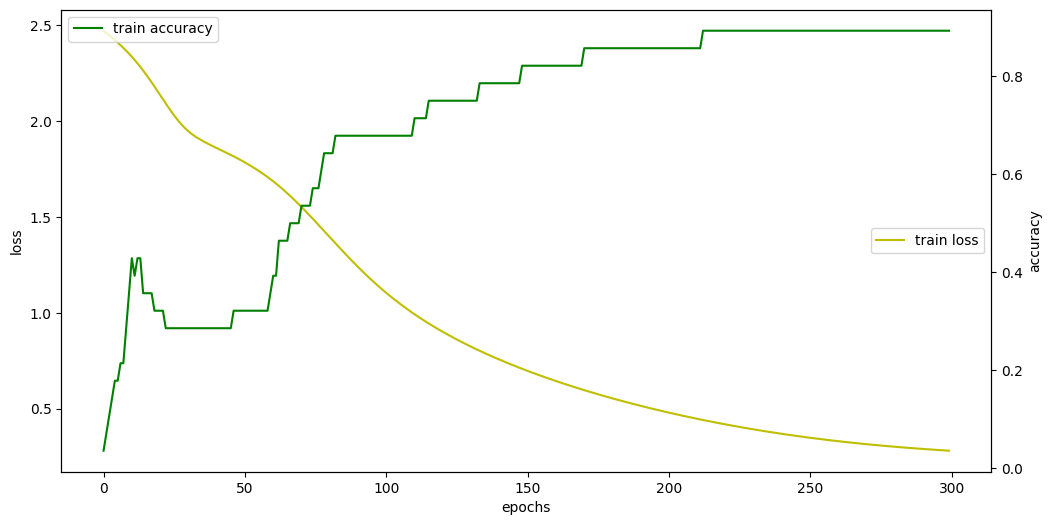

In [78]:
# 그래프만 그리자
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()



## 1.6 모델 사용하기

In [99]:
input_word = input('입력 단어 : ')
encoded = t.texts_to_sequences([input_word])
pad_encoded = pad_sequences(sequences=encoded, 
                           maxlen=5, padding='pre')
print('입력데이터 :', pad_encoded)
result = model.predict(pad_encoded, verbose=0).argmax()
word = t.index_word.get(result)
print('예측된 단어 :', word)

입력 단어 : 말이
입력데이터 : [[0 0 0 0 1]]
예측된 단어 : 고와야


# 2. 다음 문맥 예측해보기

In [101]:
# 같은 특정 단어를 주고. 그 이후에 올 단어 n개 예측
def sentence_generation(current_word, n):
    # print('입력 단어 : ', current_word)
    for i in range(1, n+1):
        # current_word 를 숫자로 바꾸고
        encoded = t.texts_to_sequences([current_word])[0]
        # print(encoded)
        input_data = pad_sequences([encoded], maxlen=my_len-1, padding='pre')
        result = model.predict(input_data, verbose=0).argmax()
        word = t.index_word[result]
        current_word = current_word+' '+word
        # print(f'{i}번째 생성 문맥 : {current_word} ({encoded} {result})')
    return current_word

# '경마장에' 뒤에 나올 3개 단어 예측하기
sentence_generation('경마장에', 3)

'경마장에 있는 말이 뛰고'